In [40]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Fijar semilla para garantizar la reproducibilidad exigida por la cátedra
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("🌱 Semilla 42 establecida localmente.")

🌱 Semilla 42 establecida localmente.


In [41]:
class CandlestickDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        """
        csv_file: Ruta al CSV indexado (train, val o test)
        img_dir: Carpeta 'data/raw' donde residen las imágenes y los .txt de Roboflow
        transform: Pipeline de transformaciones de PyTorch
        """
        # Cargar el mapeo generado por el script split_dataset.py
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        # Mapeo oficial de las 8 clases del dataset de Roboflow
        self.classes = [
            'Hammer', 'Inverted_Hammer', 'Bullish Engulfing', 'Bearish Engulfing',
            'Bullish Insidebar', 'Bearish Insidebar', 'insidebar', 'Bullish-Bearish'
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # 1. Obtener las rutas relativas desde el CSV
        img_relative_path = self.annotations.iloc[index, 0]
        label_relative_path = self.annotations.iloc[index, 1]
        
        # Ajustar la ruta para que el notebook parado en dev/ encuentre la carpeta data/
        img_path = os.path.join("..", img_relative_path)
        label_path = os.path.join("..", label_relative_path)
        
        # Cargar la imagen con OpenCV y aplicar resize a 224x224
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"No se pudo cargar la imagen: {img_path}")
            
        img_bgr = cv2.resize(img_bgr, (224, 224))
        h, w, _ = img_bgr.shape 
        
        # 2. ELIMINAR EL FONDO BLANCO CON OPENCV (VERSIÓN CALIBRADA ROBUSTA)
        
        # Convertimos a espacio HSV (ideal para segmentar colores bloqueando el brillo de fondo)
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        
        # Definimos rangos para capturar las velas (Verdes, Rojas, Tianes y Naranjas de tus muestras)
        # Rango para componentes Verdes / Cianes
        lower_green = np.array([35, 40, 40])
        upper_green = np.array([95, 255, 255])
        
        # Rango para componentes Rojas / Naranjas (El rojo en HSV da la vuelta en el rango 0-10 y 170-180)
        lower_red1 = np.array([0, 40, 40])
        upper_red1 = np.array([15, 255, 255])
        lower_red2 = np.array([165, 40, 40])
        upper_red2 = np.array([180, 255, 255])
        
        # Crear máscaras individuales
        mask_g = cv2.inRange(hsv, lower_green, upper_green)
        mask_r1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask_r2 = cv2.inRange(hsv, lower_red2, upper_red2)
        
        # Unimos todas las máscaras: esto representa ÚNICAMENTE los cuerpos y mechas de las velas
        velas_mask = mask_g | mask_r1 | mask_r2
        
        # Todo lo que NO sea una vela del color definido, se fuerza a NEGRO absoluto (0, 0, 0)
        # Esto elimina volumen blanco inferior, textos de marcas de agua y cuadrículas finas
        img_bgr[velas_mask == 0] = [0, 0, 0]
        
        # Convertir de BGR (OpenCV) a RGB y luego a una imagen de PIL para PyTorch
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(img_rgb)
        
        # 3. Inicializar listas para las Bounding Boxes (Cajas) y etiquetas (¡ESTO FALTA EN TU COPIA!)
        boxes = []
        labels = []
        
        # Leer las anotaciones del archivo .txt (Formato YOLOv8: class_id x_center y_center width height)
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_c, y_c, bbox_w, bbox_h = map(float, line.split())
                    
                    # Convertir el formato YOLO normalizado a coordenadas absolutas en píxeles [xmin, ymin, xmax, ymax]
                    xmin = (x_c - bbox_w / 2) * w
                    ymin = (y_c - bbox_h / 2) * h
                    xmax = (x_c + bbox_w / 2) * w
                    ymax = (y_c + bbox_h / 2) * h
                    
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(class_id))
        
        # Convertir las listas a tensores de PyTorch
        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([index])
        }

        # 4. Aplicar el pipeline de transformaciones
        if self.transform:
            image = self.transform(image)
            
        return image, target

# Función de colación personalizada obligatoria para detección de objetos
def collate_fn(batch):
    return tuple(zip(*batch))

In [45]:
IMG_SIZE = 224  # Resolución nativa de tus capturas de Roboflow

# Transformaciones de ENTRENAMIENTO (Con Data Augmentation permitido)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.0, contrast=0.0, saturation=0.0), # Soporte fondos claros/oscuros
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones de VALIDACIÓN Y TESTEO (Conjuntos limpios, sin aumentos de datos)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("🎯 Pipelines de transformación configurados con sentido financiero.")

🎯 Pipelines de transformación configurados con sentido financiero.


In [46]:
BATCH_SIZE = 16

# Instanciar los tres conjuntos apuntando a los CSV generados por el script
train_dataset = CandlestickDataset(csv_file='../data/train.csv', img_dir='../data/raw', transform=train_transform)
val_dataset = CandlestickDataset(csv_file='../data/val.csv', img_dir='../data/raw', transform=val_test_transform)
test_dataset = CandlestickDataset(csv_file='../data/test.csv', img_dir='../data/raw', transform=val_test_transform)

# Crear los cargadores fijando el mezclado (shuffle=True) exclusivamente en entrenamiento
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Cargadores listos. Lotes de entrenamiento configurados con tamaño: {BATCH_SIZE}")

✅ Cargadores listos. Lotes de entrenamiento configurados con tamaño: 16


📊 REPORTE DE DIMENSIONES PARA LA DEFENSA ORAL
• Tamaño del lote (Batch Size): 16
• Dimensiones del Tensor Imagen [Canales, Alto, Ancho]: torch.Size([3, 224, 224])
• Rango numérico tras normalización: Mín=-2.12, Máx=2.50



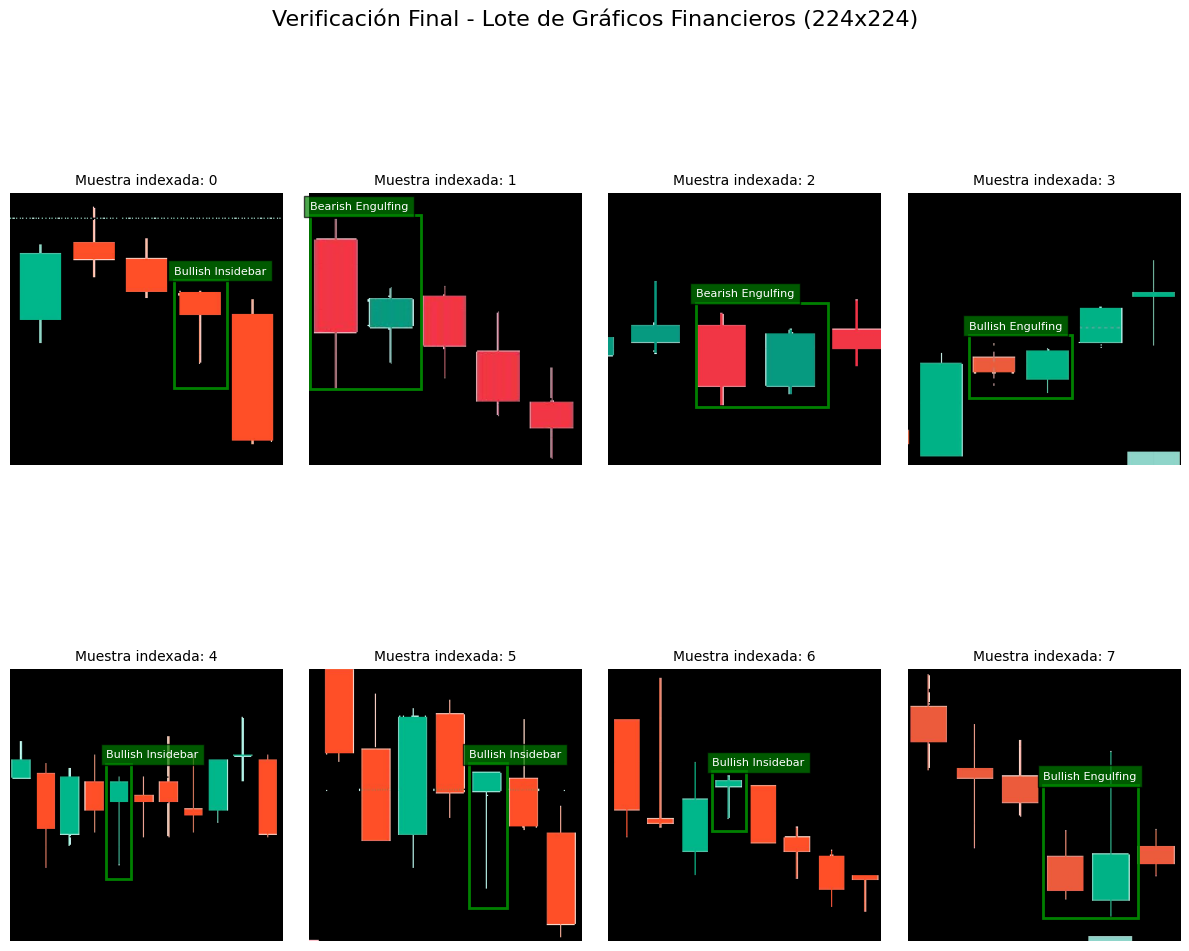

In [47]:
def unnormalize(tensor):
    """Desnormaliza el tensor para que Matplotlib lo dibuje con sus colores reales."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Extraer el primer lote del DataLoader de entrenamiento
images, targets = next(iter(train_loader))

# Reportar dimensiones oficiales del tensor en consola para la defensa oral
print("="*50)
print("📊 REPORTE DE DIMENSIONES PARA LA DEFENSA ORAL")
print("="*50)
print(f"• Tamaño del lote (Batch Size): {len(images)}")
print(f"• Dimensiones del Tensor Imagen [Canales, Alto, Ancho]: {images[0].shape}")
print(f"• Rango numérico tras normalización: Mín={images[0].min().item():.2f}, Máx={images[0].max().item():.2f}")
print("="*50 + "\n")

# Configurar cuadrícula de 2x2 para mostrar 4 muestras en simultáneo
CANT_MUESTRAS = 8
fig, axes = plt.subplots(2, 4, figsize=(12, 12))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

for idx in range(CANT_MUESTRAS):
    ax = axes[idx]
    
    # Desnormalizar y convertir a formato NumPy legible por Matplotlib
    img_vis = unnormalize(images[idx]).permute(1, 2, 0).numpy()
    img_vis = np.clip(img_vis, 0, 1)
    
    ax.imshow(img_vis)
    ax.axis('off')
    ax.set_title(f"Muestra indexada: {idx}", fontsize=10)
    
    # Extraer cajas y etiquetas de la muestra actual
    boxes = targets[idx]["boxes"]
    labels = targets[idx]["labels"]
    
    # Dibujar cada recuadro de patrón detectado sobre el gráfico de trading
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box.numpy()
        width = xmax - xmin
        height = ymax - ymin
        
        # Añadir rectángulo verde
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='g', facecolor='none')
        ax.add_patch(rect)
        
        # Añadir texto de la clase financiera
        class_name = train_dataset.classes[label.item()]
        ax.text(xmin, ymin - 5, class_name, color='white', fontsize=8, bbox=dict(facecolor='green', alpha=0.7))

plt.suptitle("Verificación Final - Lote de Gráficos Financieros (224x224)", fontsize=16, y=0.95)
plt.tight_layout()
plt.show()